In [1]:
%load_ext autoreload
%matplotlib widget

from helper_funcs import *
from collections import defaultdict
import numpy as np
import pandas as pd


dirs = get_dirs(root=r"c:\\Users\\setht\\Dropbox\\Citadel\\GitHub\\otocoherence")
dpi = 300

In [4]:
# Get data
def get_data(T_xi_type, cgram=False):
    data = defaultdict(lambda: defaultdict(dict))

    # Read df
    df = pd.read_excel(os.path.join(
        dirs["results"], rf"soae_T_xi [{T_xi_type}].xlsx"
    ))

    dfs = {}
    dfs["P"] = df[df["mode"]=="P"]
    dfs["phi"] = df[df["mode"]=="phi"]
    
    # Gather everything into lists


    for mode in ["phi", "P"]:
        for prop in ["T_xi", "f0_max", "f0_fit", "species", "wf_idx"]:
            data[T_xi_type][mode][prop] = np.array(dfs[mode][prop])
        # Calculate derived data
        data[T_xi_type][mode]["N_xi"] = data[T_xi_type][mode]["T_xi"] * data[T_xi_type][mode]["f0_max"]
        data[T_xi_type][mode]["inv_T_xi"] = 1/(data[T_xi_type][mode]["T_xi"])
    data[T_xi_type]["T_xi_diffs"] = data[T_xi_type]["P"]["T_xi"] - data[T_xi_type]["phi"]["T_xi"]
    data[T_xi_type]["N_xi_diffs"] = data[T_xi_type]["P"]["N_xi"] - data[T_xi_type]["phi"]["N_xi"]

    if cgram:
        dfs["cgram"] = pd.read_excel(os.path.join(dirs["results"], f"soae_T_xi_cgram [{T_xi_type}, T_xi_thresh={T_xi_thresh}, fmin={fmin}, hpf_cf={hpf_cf}].xlsx"))

        # Ditto for cgram
        for prop in ["T_xi", "f0", "species", "wf_idx"]:
            data[T_xi_type]["cgram"][prop] = np.array(dfs["cgram"][prop])
        data[T_xi_type]["cgram"]["N_xi"] = data[T_xi_type]["cgram"]["T_xi"] * data[T_xi_type]["cgram"]["f0"]
        data[T_xi_type]["cgram"]["inv_T_xi"] = 1/(data[T_xi_type]["cgram"]["T_xi"])

    return data

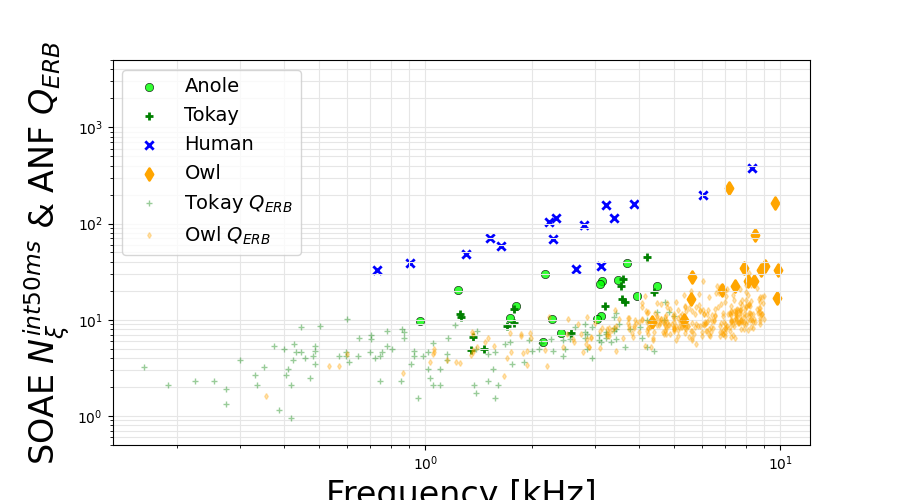

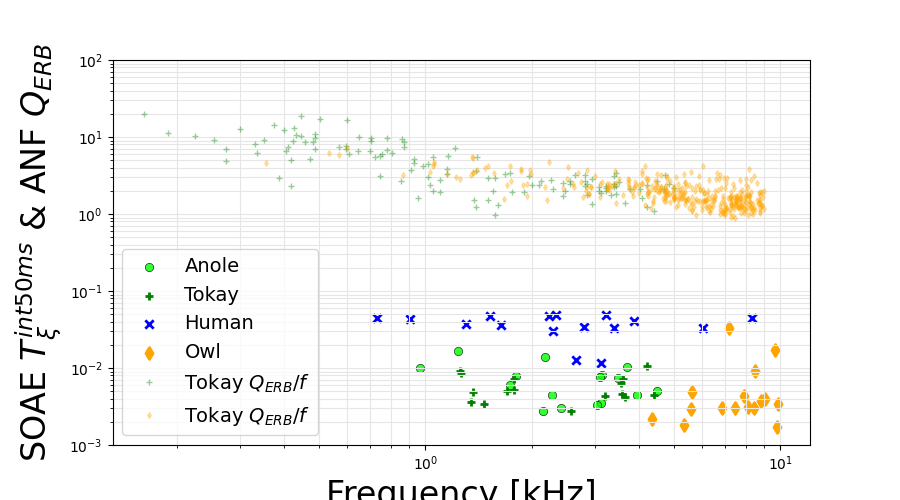

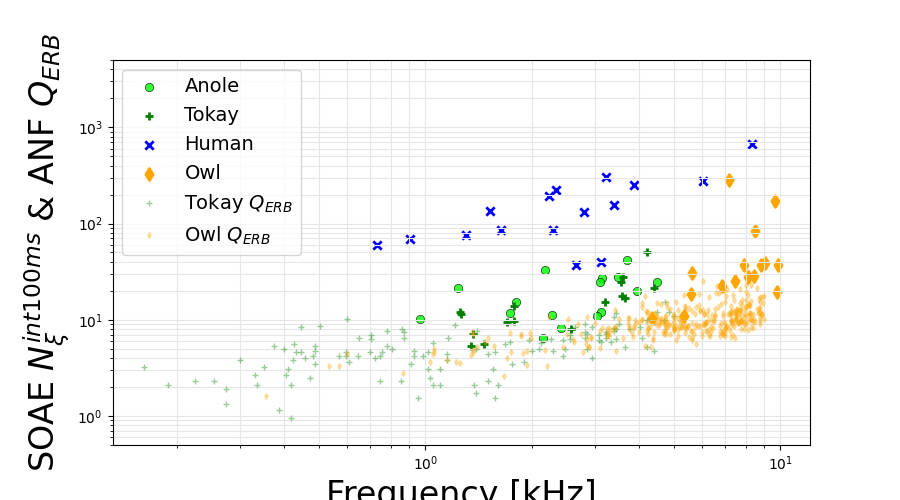

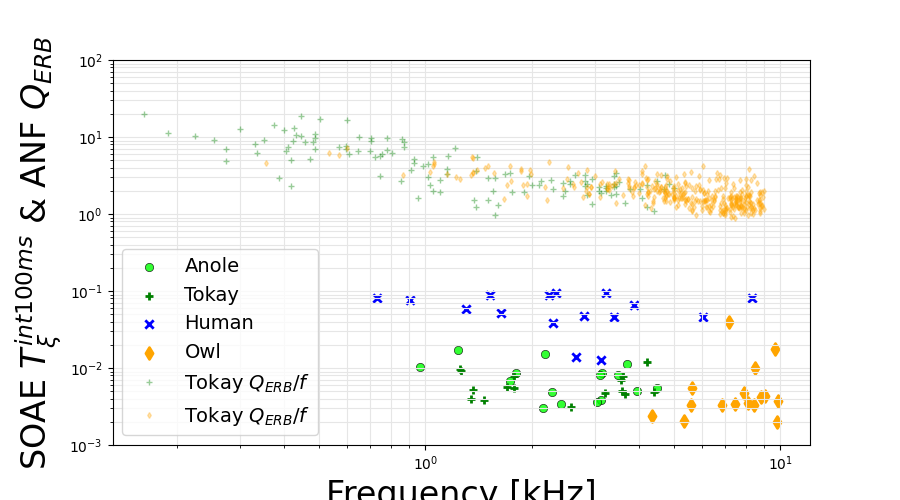

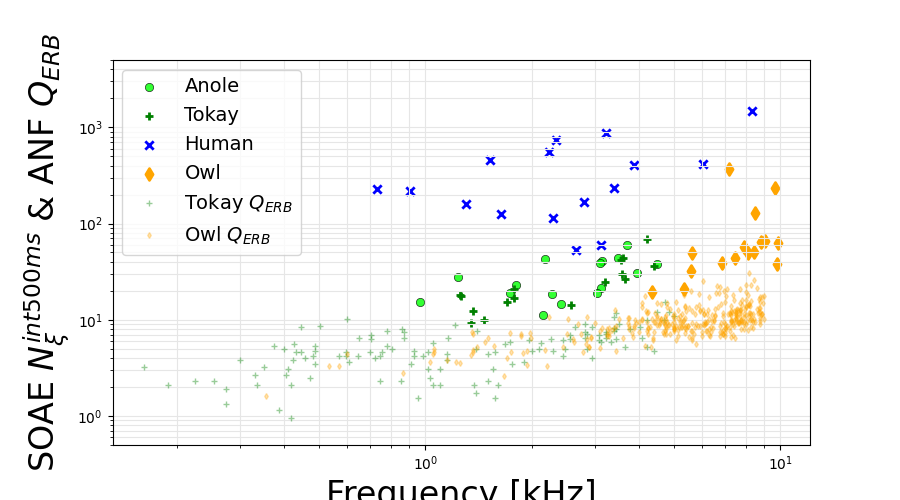

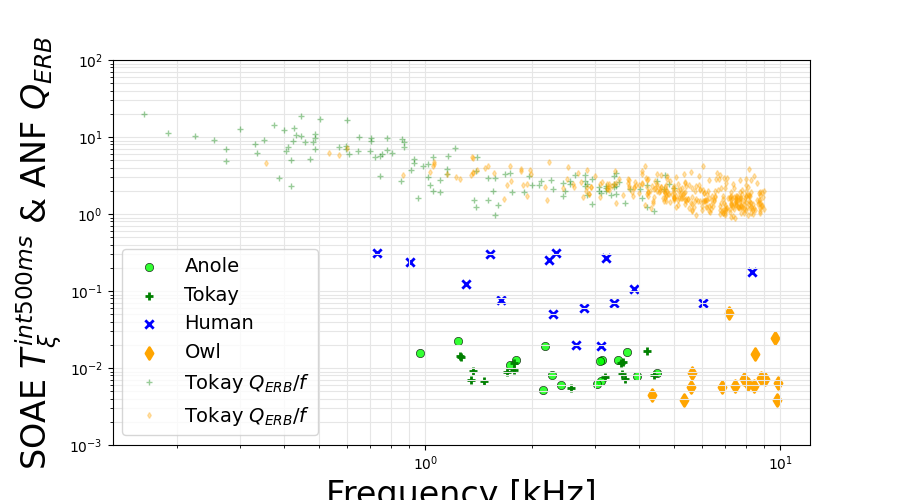

In [13]:
for T_xi_type in ["int 50ms", "int 100ms", "int 500ms"]:
    data = get_data(T_xi_type, cgram=False)


    "Qerb and X_xi vs Freq"
    for tc in ["N_xi", "T_xi"]:

        # ======================================================
        fig_fp = os.path.join(dirs["figs"], f"Qerb and {tc} vs Freq [{T_xi_type}].jpg")


        # --- owl ANF tuning curve data (Excel files provided by Christine)
        fp_ANFfileOwl = os.path.join(dirs["data"], "Owl Qerb_analysis_CK2.xlsx")
        fp_ANFfileTokay = os.path.join(dirs["data"], "manley99.txt")
        # ======================================================


        # --- read in data
        owlANF = pd.read_excel(fp_ANFfileOwl)
        toakyANFq10 = np.loadtxt(fp_ANFfileTokay)

        # =========================
        # deal w/ owl ANF vals
        owlANF = owlANF[1:]  # discard first line
        freqANFowl = owlANF["CF"].values
        QerbANFowl = owlANF["Qerb"].values

        # =========================
        # deal w/ tokay ANF vals
        freqANFtokay = toakyANFq10[:, 0]
        QerbANFtokay = 6 * toakyANFq10[:, 1] * 1000 / np.pi
        # convert to Qerb(?) via Bergevin & Shera 2010

        if tc == "T_xi":
            QerbANFtokay, QerbANFowl = QerbANFtokay / freqANFtokay, QerbANFowl / freqANFowl

        # =======================================================================
        # ==== visualize
        plt.close("all")
        # ------------------------------------------------
        plt.figure(figsize=(9, 5))
        alphas = {"Anole": 0.8, "Owl": 1, "Human": 1, "Tokay": 1}
        markers = {"Anole": "o", "Owl": "d", "Human": "x", "Tokay": "+"}
        colors = {"Anole": "k", "Owl": "orange", "Human": "blue", "Tokay": "green"}
        mews = {"Anole": 0.5, "Owl": 2, "Human": 2, "Tokay": 2}
        mfcs = {"Anole": "lime", "Owl": "orange", "Human": "blue", "Tokay": "green"}
        # Plot
        for s in set(data[T_xi_type]["phi"]["species"]):
            mask = [sp == s for sp in data[T_xi_type]["phi"]["species"]]

            plt.scatter(
                (data[T_xi_type]["phi"]["f0_max"] / 1000)[mask],
                data[T_xi_type]["phi"][tc][mask],
                marker=markers[s],
                color=colors[s],
                lw=mews[s],
                alpha=alphas[s],
                s=36,
                facecolors=mfcs[s],
                label=s,
            )


        # Plot Q_ERB
        plt.plot(
            freqANFtokay,
            QerbANFtokay,
            "+",
            color="green",
            alpha=0.4,
            ms=4,
            lw=1,
            markerfacecolor="green",
            label=r"Tokay $Q_{ERB}$" if tc == "N_xi" else r"Tokay $Q_{ERB}/f$",
        )

        plt.plot(
            freqANFowl,
            QerbANFowl,
            "d",
            color="orange",
            alpha=0.3,
            ms=3,
            lw=1,
            markerfacecolor="orange",
            label=r"Owl $Q_{ERB}$" if tc == "N_xi" else r"Tokay $Q_{ERB}/f$",
        )

        # ---
        fsz=24
        plt.xscale("log")
        plt.yscale("log")
        # plt.xlim([0.1, 12])
        if tc=="N_xi":
            plt.ylim(0.5, 5e3)
        elif tc=="T_xi":
            plt.ylim(1e-3, 1e2)
        plt.xlabel("Frequency [kHz]", fontsize=fsz)
        plt.ylabel(rf"SOAE ${tc[0]}_\xi^{{{T_xi_type}}}$ & ANF $Q_{{ERB}}$", fontsize=fsz)
        plt.grid(True, which="both", ls="-", color="0.9")
        plt.legend(fontsize=fsz-10)

        plt.savefig(fig_fp, dpi=dpi, bbox_inches="tight")
        plt.show()

In [ ]:
"Qerb and X_xi vs Freq - CGRAM"
for tc in ["N_xi"]:
    for T_xi_type in ["int"]:
        data = get_data(T_xi_type, cgram=False)
    
        # ======================================================
        fig_fp = os.path.join(dirs["figs"], f"Qerb and {tc} vs Freq - CGRAM [{T_xi_type}, T_xi_thresh={T_xi_thresh}, fmin={fmin}, hpf_cf={hpf_cf}].jpg")


        # --- owl ANF tuning curve data (Excel files provided by Christine)
        fp_ANFfileOwl = os.path.join(dirs["data"], "Owl Qerb_analysis_CK2.xlsx")
        fp_ANFfileTokay = os.path.join(dirs["data"], "manley99.txt")
        # ======================================================


        # --- read in data
        owlANF = pd.read_excel(fp_ANFfileOwl)
        toakyANFq10 = np.loadtxt(fp_ANFfileTokay)

        # =========================
        # deal w/ owl ANF vals
        owlANF = owlANF[1:]  # discard first line
        freqANFowl = owlANF["CF"].values
        QerbANFowl = owlANF["Qerb"].values

        # =========================
        # deal w/ tokay ANF vals
        freqANFtokay = toakyANFq10[:, 0]
        QerbANFtokay = 6 * toakyANFq10[:, 1] * 1000 / np.pi
        # convert to Qerb(?) via Bergevin & Shera 2010

        # =======================================================================
        # ==== visualize
        plt.close("all")
        # ------------------------------------------------
        plt.figure(figsize=(9, 5))
        alphas = {"Anole": 0.8, "Owl": 1, "Human": 1, "Tokay": 1}
        markers = {"Anole": "o", "Owl": "d", "Human": "x", "Tokay": "+"}
        colors = {"Anole": "k", "Owl": "orange", "Human": "blue", "Tokay": "green"}
        mews = {"Anole": 0.5, "Owl": 2, "Human": 2, "Tokay": 2}
        mfcs = {"Anole": "lime", "Owl": "orange", "Human": "blue", "Tokay": "green"}
        # Plot
        for s in set(data[T_xi_type]["cgram"]["species"]):
            mask = [sp == s for sp in data[T_xi_type]["cgram"]["species"]]

            plt.scatter(
                (data[T_xi_type]["cgram"]["f0"] / 1000)[mask],
                data[T_xi_type]["cgram"][tc][mask],
                marker=markers[s],
                color=colors[s],
                lw=mews[s],
                alpha=alphas[s],
                s=36,
                facecolors=mfcs[s],
                label=s,
            )


        # Plot Q_ERB
        plt.plot(
            freqANFtokay,
            QerbANFtokay,
            "+",
            color="green",
            alpha=0.4,
            ms=4,
            lw=1,
            markerfacecolor="green",
            label=r"Tokay $Q_{ERB}$",
        )

        plt.plot(
            freqANFowl,
            QerbANFowl,
            "d",
            color="orange",
            alpha=0.3,
            ms=3,
            lw=1,
            markerfacecolor="orange",
            label=r"Owl $Q_{ERB}$",
        )

        # ---
        fsz=24
        plt.xscale("log")
        plt.yscale("log")
        # plt.xlim([0.1, 12])
        # plt.ylim([0.8,2000])
        plt.xlabel("Frequency [kHz]", fontsize=fsz)
        plt.ylabel(rf"SOAE ${tc[0]}_\xi^{{{T_xi_type}}}$ & ANF $Q_{{ERB}}$", fontsize=fsz)
        plt.title(rf"${tc[0]}_\xi$ Spectrum")
        plt.grid(True, which="both", ls="-", color="0.9")
        # plt.legend(fontsize=fsz-10)
        
        plt.savefig(fig_fp, dpi=dpi, bbox_inches="tight")
        plt.show()

In [ ]:
"Standard Autocorrelation vs Phase-Only"
T_xi_type = "int"
data = get_data(T_xi_type, cgram=False)
for tc in ["N_xi", "T_xi"]:
    # Initialize plot
    plt.figure(figsize=(10, 8))
    plt.suptitle(rf"Standard Autocorrelation $C_\xi^P$ vs Phase-Only $C_\xi^\phi$ (${tc[0]}_\xi^{{{T_xi_type}}}$)")
    fn_plot = f'Phase only vs ACF ({tc[0]}_xi_{T_xi_type}).jpg'

    f0_maxs = data[T_xi_type]["P"]["f0_max"]
    speciess = data[T_xi_type]["P"]["species"]

    if np.max(np.abs(f0_maxs-data[T_xi_type]["phi"]["f0_max"])) > 0 or np.any(speciess != data[T_xi_type]["phi"]["species"]):
        raise ValueError("Frequencies and species should agree between modes!")


    markers = {
        "Anole": ("limegreen", "o"),
        "Owl": ("orange", "d"),
        "Human": ("blue", "x"),
        "Tokay": ("green", "+"),
    }

    unique_species = ["Anole", "Human", "Tokay", "Owl"]

    for species in unique_species:
        f0_maxs_plot = [this_f0_max for this_f0_max, this_species in zip(f0_maxs, speciess) if this_species == species]
        if tc == "N_xi":
            N_xi_diff_plot = [this_N_xi_diff for this_N_xi_diff, this_species in zip(data[T_xi_type]["N_xi_diffs"], speciess) if this_species == species]
            plt.scatter(f0_maxs_plot, N_xi_diff_plot, 
                        label=species,
                        color=markers[species][0],
                        marker=markers[species][1],
                        s=80)
        elif tc == "T_xi":
            T_xi_diff_plot = [this_T_xi_diff for this_T_xi_diff, this_species in zip(data[T_xi_type]["T_xi_diffs"], speciess) if this_species == species]
            plt.scatter(f0_maxs_plot, T_xi_diff_plot, 
                        label=species,
                        color=markers[species][0],
                        marker=markers[species][1],
                        s=80)
    plt.hlines(0, np.min(f0_maxs), np.max(f0_maxs))
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Time Constant from ACF - Phase Only")
    plt.legend()
    plt.savefig(os.path.join(dirs["figs"], fn_plot), dpi=dpi)